In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
#Load
df = pd.read_csv(r"C:\Users\sreej\OneDrive\Desktop\Power BI PROJECT\supply chain project\supply_chain_data.csv")

print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
print(df.duplicated().sum())


(100, 24)
Product type                object
SKU                         object
Price                      float64
Availability                 int64
Number of products sold      int64
Revenue generated          float64
Customer demographics       object
Stock levels                 int64
Lead times                   int64
Order quantities             int64
Shipping times               int64
Shipping carriers           object
Shipping costs             float64
Supplier name               object
Location                    object
Lead time                    int64
Production volumes           int64
Manufacturing lead time      int64
Manufacturing costs        float64
Inspection results          object
Defect rates               float64
Transportation modes        object
Routes                      object
Costs                      float64
dtype: object
Product type               0
SKU                        0
Price                      0
Availability               0
Number of products s

In [3]:
#Clean column names
df.columns = (df.columns
              .str.strip()
              .str.lower()
              .str.replace(' ', '_')
              .str.replace(r'[^\w]', '', regex=True))

#Handle nulls
df['lead_times'].fillna(df['lead_times'].median(), inplace=True)
df['defect_rates'].fillna(0, inplace=True)

#Fix data types
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['revenue_generated'] = pd.to_numeric(df['revenue_generated'], errors='coerce')

#Feature Engineering
df['profit_margin'] = (
    (df['revenue_generated'] - df['costs']) / df['revenue_generated']
).round(4)

df['on_time_flag'] = np.where(
    df['shipping_times'] <= df['lead_times'], 1, 0
)

df['delay_days'] = (df['shipping_times'] - df['lead_times']).clip(lower=0)

df['defect_risk_tier'] = pd.cut(
    df['defect_rates'],
    bins=[0, 0.02, 0.05, 1.0],
    labels=['Low', 'Medium', 'High']
)

C:\Users\sreej\AppData\Local\Temp\ipykernel_16076\2959281683.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['lead_times'].fillna(df['lead_times'].median(), inplace=True)
C:\Users\sreej\AppData\Local\Temp\ipykernel_16076\2959281683.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as

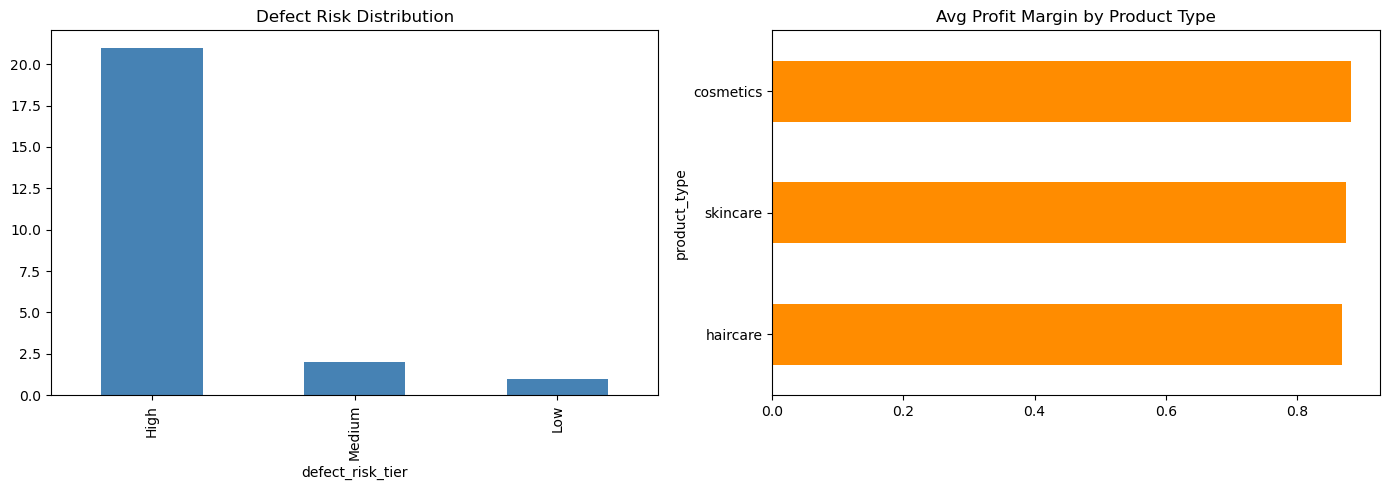

Saved to: c:\Users\sreej\OneDrive\Desktop\Power BI PROJECT\supply chain project\assets\screenshots\eda_overview.png
Cleaned data exported


In [4]:
#EDA plots (save for README)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['defect_risk_tier'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Defect Risk Distribution')

df.groupby('product_type')['profit_margin'].mean().sort_values().plot(
    kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Avg Profit Margin by Product Type')

plt.tight_layout()
os.makedirs('assets/screenshots', exist_ok=True)
plt.savefig('assets/screenshots/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

#Export cleaned data
print("Saved to:", os.path.abspath('assets/screenshots/eda_overview.png'))
print("Cleaned data exported")


In [5]:
save_path = r"C:\Users\sreej\OneDrive\Desktop\Power BI PROJECT\supply chain project.csv"
df.to_csv(save_path, index=False)

print(f" Saved: {save_path}")
print(f" Shape: {df.shape}")

 Saved: C:\Users\sreej\OneDrive\Desktop\Power BI PROJECT\supply chain project.csv
 Shape: (100, 28)


In [6]:
import pandas as pd
df = pd.read_csv(r"C:\Users\sreej\OneDrive\Desktop\Power BI PROJECT\supply chain project\supply_chain_data.csv")
print(df.columns.tolist())

['Product type', 'SKU', 'Price', 'Availability', 'Number of products sold', 'Revenue generated', 'Customer demographics', 'Stock levels', 'Lead times', 'Order quantities', 'Shipping times', 'Shipping carriers', 'Shipping costs', 'Supplier name', 'Location', 'Lead time', 'Production volumes', 'Manufacturing lead time', 'Manufacturing costs', 'Inspection results', 'Defect rates', 'Transportation modes', 'Routes', 'Costs']


In [7]:
import pandas as pd
import numpy as np
import os

# ── LOAD RAW FILE ──────────────────────────────────────────────────────
df = pd.read_csv(r"C:\Users\sreej\OneDrive\Desktop\Power BI PROJECT\supply chain project\supply_chain_data.csv")

# ── STEP 1: CLEAN COLUMN NAMES ─────────────────────────────────────────
df.columns = (df.columns.str.strip().str.lower()
              .str.replace(' ', '_', regex=False)
              .str.replace(r'[^\w]', '', regex=True))

# ── STEP 2: RENAME ─────────────────────────────────────────────────────
df = df.rename(columns={
    'lead_times':              'supply_lead_time_days',
    'lead_time':               'supplier_lead_time_days',
    'number_of_products_sold': 'units_sold',
    'manufacturing_lead_time': 'mfg_lead_time_days',
})

# ── STEP 3: FIX TYPES ──────────────────────────────────────────────────
numeric_cols = ['price','availability','units_sold','revenue_generated',
                'stock_levels','supply_lead_time_days','order_quantities',
                'shipping_times','shipping_costs','supplier_lead_time_days',
                'production_volumes','mfg_lead_time_days','manufacturing_costs',
                'defect_rates','costs']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# ── STEP 4: STANDARDISE CATEGORICALS ───────────────────────────────────
cat_cols = ['product_type','customer_demographics','shipping_carriers',
            'supplier_name','location','inspection_results',
            'transportation_modes','routes']
for col in cat_cols:
    df[col] = df[col].str.strip().str.title()

# ── STEP 5: FEATURE ENGINEERING ────────────────────────────────────────
df['profit_margin_pct']   = np.where(df['revenue_generated'] > 0,
    ((df['revenue_generated'] - df['costs']) / df['revenue_generated'] * 100).round(2), 0)
df['on_time_flag']        = np.where(df['shipping_times'] <= df['supply_lead_time_days'], 1, 0)
df['delay_days']          = (df['shipping_times'] - df['supply_lead_time_days']).clip(lower=0)
df['defect_risk_tier']    = pd.cut(df['defect_rates'], bins=[0,2.0,3.5,5.0],
                                   labels=['Low','Medium','High'], include_lowest=True)
df['revenue_per_unit']    = np.where(df['units_sold'] > 0,
                                     (df['revenue_generated'] / df['units_sold']).round(2), 0)
df['stock_health']        = pd.cut(df['stock_levels'], bins=[0,20,50,100],
                                   labels=['Critical','Watch','Healthy'], include_lowest=True)
df['total_cost']          = df['costs'] + df['shipping_costs']
df['cost_efficiency_pct'] = np.where(df['revenue_generated'] > 0,
    (df['total_cost'] / df['revenue_generated'] * 100).round(2), 0)

print(" Cleaning done:", df.shape)
print("Columns:", df.columns.tolist())

# ── STEP 6: BUILD DIMENSION TABLES ─────────────────────────────────────
dim_product = (df[['sku','product_type','price','availability']]
               .drop_duplicates().reset_index(drop=True).copy())
dim_product.insert(0, 'product_key', range(1, len(dim_product)+1))

dim_supplier = (df[['supplier_name','location','supplier_lead_time_days',
                    'production_volumes','mfg_lead_time_days','manufacturing_costs']]
                .drop_duplicates(subset=['supplier_name','location'])
                .reset_index(drop=True).copy())
dim_supplier.insert(0, 'supplier_key', range(1, len(dim_supplier)+1))

dim_shipping = (df[['shipping_carriers','transportation_modes','routes']]
                .drop_duplicates().reset_index(drop=True).copy())
dim_shipping.insert(0, 'shipping_key', range(1, len(dim_shipping)+1))

dim_customer = pd.DataFrame({
    'customer_key':          [1,        2,      3,           4],
    'customer_demographics': ['Female', 'Male', 'Non-Binary', 'Unknown']
})

dim_inspection = pd.DataFrame({
    'inspection_key':     [1,      2,      3],
    'inspection_results': ['Pass', 'Fail', 'Pending']
})

# ── STEP 7: BUILD FACT TABLE ───────────────────────────────────────────
fact = df.copy()
fact = fact.merge(dim_product[['product_key','sku']], on='sku', how='left')
fact = fact.merge(dim_supplier[['supplier_key','supplier_name','location']],
                  on=['supplier_name','location'], how='left')
fact = fact.merge(dim_shipping[['shipping_key','shipping_carriers',
                                'transportation_modes','routes']],
                  on=['shipping_carriers','transportation_modes','routes'], how='left')
fact = fact.merge(dim_customer[['customer_key','customer_demographics']],
                  on='customer_demographics', how='left')
fact = fact.merge(dim_inspection[['inspection_key','inspection_results']],
                  on='inspection_results', how='left')

fact_cols = [
    'product_key','supplier_key','shipping_key','customer_key','inspection_key',
    'units_sold','revenue_generated','stock_levels','stock_health',
    'order_quantities','supply_lead_time_days','shipping_times','shipping_costs',
    'costs','total_cost','defect_rates','defect_risk_tier',
    'profit_margin_pct','on_time_flag','delay_days','revenue_per_unit','cost_efficiency_pct'
]

# Check for any missing columns before selecting
missing = [col for col in fact_cols if col not in fact.columns]
print("\n Missing columns:", missing if missing else "None — all good!")

fact_table = fact[fact_cols].copy()

# ── STEP 8: VALIDATE ───────────────────────────────────────────────────
print("\n Null check on keys:")
print(fact_table[['product_key','supplier_key','shipping_key',
                  'customer_key','inspection_key']].isnull().sum())

# ── STEP 9: EXPORT ─────────────────────────────────────────────────────
base = r"C:\Users\sreej\OneDrive\Desktop\Power BI PROJECT\supply chain project\star_schema"
os.makedirs(base, exist_ok=True)

dim_product.to_csv(f'{base}\\dim_product.csv',        index=False)
dim_supplier.to_csv(f'{base}\\dim_supplier.csv',      index=False)
dim_shipping.to_csv(f'{base}\\dim_shipping.csv',      index=False)
dim_customer.to_csv(f'{base}\\dim_customer.csv',      index=False)
dim_inspection.to_csv(f'{base}\\dim_inspection.csv',  index=False)
fact_table.to_csv(f'{base}\\fact_supply_chain.csv',   index=False)

print("\n All 6 tables exported to:", base)
print(f"   dim_product    → {dim_product.shape}")
print(f"   dim_supplier   → {dim_supplier.shape}")
print(f"   dim_shipping   → {dim_shipping.shape}")
print(f"   dim_customer   → {dim_customer.shape}")
print(f"   dim_inspection → {dim_inspection.shape}")
print(f"   fact_table     → {fact_table.shape}")

 Cleaning done: (100, 32)
Columns: ['product_type', 'sku', 'price', 'availability', 'units_sold', 'revenue_generated', 'customer_demographics', 'stock_levels', 'supply_lead_time_days', 'order_quantities', 'shipping_times', 'shipping_carriers', 'shipping_costs', 'supplier_name', 'location', 'supplier_lead_time_days', 'production_volumes', 'mfg_lead_time_days', 'manufacturing_costs', 'inspection_results', 'defect_rates', 'transportation_modes', 'routes', 'costs', 'profit_margin_pct', 'on_time_flag', 'delay_days', 'defect_risk_tier', 'revenue_per_unit', 'stock_health', 'total_cost', 'cost_efficiency_pct']

 Missing columns: None — all good!

 Null check on keys:
product_key       0
supplier_key      0
shipping_key      0
customer_key      0
inspection_key    0
dtype: int64

 All 6 tables exported to: C:\Users\sreej\OneDrive\Desktop\Power BI PROJECT\supply chain project\star_schema
   dim_product    → (100, 5)
   dim_supplier   → (25, 7)
   dim_shipping   → (33, 4)
   dim_customer   → (4, 